# **Homework Assignment 1 – Exploratory Data Analysis (EDA)**

**Student Name:** Maya Reuveni

**ID Number:** 322909821

**Course:** Data Science

**Lecturer:** Dr. Uri Itai

**Teaching Assistant:** Gabriela Wagner

**2. Dataset Selection**

**2.1 Compliance with Requirements**
The selected dataset, "Supermarket Sales," strictly adheres to the assignment's technical criteria:
* **Tabular Structure:** The dataset comprises 1,000 rows and 17 columns.
* **Variable Diversity:** It features a comprehensive mix of numerical variables (e.g., `unit_cost`, `revenue`), temporal data (`date`, `time`), and categorical features (`branch`, `customer_type`).

**2.2 Data Source Description**
* **Source:** The dataset was retrieved from the Kaggle platform, specifically from a repository curated by Alex Huitron. It is published under a CC0 (Public Domain) license.
* **Data Curation & Author Expertise:** According to the dataset's documentation, this is a refined and corrected version of a widely circulated retail dataset originating from Myanmar. The curator, leveraging professional experience in the Finance and Retail sectors, restructured the headers and columns to rectify prior interpretational issues and align the metrics with real-world business standards. **Insight:** The specific identity of the supermarket chain remains undisclosed, indicating that the raw data underwent an anonymization process to protect corporate confidentiality.
* **Collection Objective:** The primary objective for publishing this dataset is to facilitate the learning and practice of Data Analytics skills. From a business perspective, the data enables Exploratory Data Analysis (EDA) aimed at identifying consumer purchasing patterns, optimizing profitability, and conducting customer segmentation.
* **Domain Knowledge Integration:** The dataset accurately encapsulates essential Retail Key Performance Indicators (KPIs), such as Cost of Goods Sold (COGS) and a 5% tax markup applied to the total purchase cost. Precision in these terms, validated by the author's financial background, is crucial for accurate profitability analysis and understanding price-demand elasticity within the retail sector.

In [2]:
import pandas as pd

# Load the dataset to verify structure and content
df = pd.read_csv('supermarket_sales.csv')

# Previewing the first 5 rows to understand the data distribution and feature semantics
# Using display() for better visual rendering in Colab
display(df.head())

# Displaying a summary of the dataframe to confirm data types and non-null counts
# This ensures compliance with the minimum requirement of 1,000 rows and 10 columns
print(df.info())

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   object 
 1   branch           1000 non-null   object 
 2   city             1000 non-null   object 
 3   customer_type    1000 non-null   object 
 4   gender_customer  1000 non-null   object 
 5   product_line     1000 non-null   object 
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   object 
 11  time             1000 non-null   object 
 12  payment_method   1000 non-null   object 
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), 



**3. Meta-Analysis of the Data**

**3.1 File Analysis**

* **File Size:** 131.44 kB.
* **Format:** Tabular dataset in CSV (Comma-Separated Values) format (`supermarket_sales.csv`).
* **Creation Date:** The dataset was last updated on the Kaggle platform approximately 3 years ago, with an expected update frequency defined as "Never." However, the data itself captures a specific historical timeframe: the first quarter of 2019 (from 01/01/2019 to 30/03/2019).
* **Data Purpose:** Beyond the original operational purpose of the supermarket (sales tracking), the objective of publishing this dataset on Kaggle under a CC0 (Public Domain) license is primarily educational. It is designed to enable the data science community to learn, practice, and apply Data Analytics skills on realistic and well-structured data.

**3.2 Data Structure**

This stage involves a preliminary exploration of the dataset's architecture and characteristics.

* **Dimensions:** The dataset consists of 1,000 rows and 17 columns.
* **Column Names:** The headers are intuitive and accurately represent their respective content (e.g., `quantity`, `unit_cost`). The logical naming convention suggests that the data underwent initial cleaning before being uploaded to Kaggle.
* **Data Types & Insights:** The dataset contains a mix of data types:
    * **Numerical:** Floating-point numbers (`float64`) for financial metrics and integers (`int64`) for quantities.
    * **Categorical:** Text-based data (`object`) for descriptive fields.
    * **Key Insight:** Both the `date` and `time` columns are currently stored as `object` (strings). To facilitate time-series analysis or temporal feature engineering later in the project, these must be converted into proper `datetime` formats.
* **Index Analysis:** The default index is a non-semantic `RangeIndex`. However, programmatic verification confirms that the `invoice_id` column is entirely unique (1,000 unique values). Therefore, `invoice_id` serves as a meaningful transaction identifier and is a primary candidate for a functional index.
* **Discussion (Purpose of Collection):** The data appears to have been collected for **operational purposes**, such as sales tracking, inventory management, and invoice generation, rather than for academic research.
* **Potential Biases:**
    1.  **Temporal Bias:** The data covers a relatively short window (3 months), which may not account for seasonal trends, holidays, or annual cycles.
    2.  **Geographical Bias:** The records are limited to three specific branches in Myanmar, meaning the findings may not be representative of consumer behavior in other regions or demographics.



In [3]:
# 1. Displaying the number of rows and columns
print(f"Dataset Shape: {df.shape}")

# 2. Listing the column names
print("\nColumn Names:")
print(df.columns.tolist())

# 3. Checking data types
print("\nData Types:")
print(df.dtypes)

# 4. Verifying if invoice_id is unique to serve as an index
is_unique = df['invoice_id'].is_unique
print(f"\nIs 'invoice_id' unique? {is_unique}")

Dataset Shape: (1000, 17)

Column Names:
['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer', 'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue', 'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income', 'rating']

Data Types:
invoice_id          object
branch              object
city                object
customer_type       object
gender_customer     object
product_line        object
unit_cost          float64
quantity             int64
5pct_markup        float64
revenue            float64
date                object
time                object
payment_method      object
cogs               float64
gm_pct             float64
gross_income       float64
rating             float64
dtype: object

Is 'invoice_id' unique? True


**4. Data Quality and Integrity**

**4.1 Missing Values**
* **Extent of Missing Data:** 0% (There are no missing values). A comprehensive check confirms that all 1,000 rows across all 17 columns are completely populated.
* **Pattern:** Not applicable, as there is no missing data.
* **Insights from the Absence of Missing Data:** This absolute completeness is highly characteristic of datasets that have undergone rigorous pre-processing prior to publication on platforms like Kaggle. It indicates that the data has been "cleaned" and does not necessarily reflect the raw reality of real-world data collection, where missing values are a common occurrence due to system failures or human entry errors.
* **Theoretical Imputation Strategy:** If missing values were present, the imputation strategy would depend on the respective variable type:
    * **Numerical Variables (e.g., `unit_cost`, `rating`):** I would utilize median imputation, as the median is more robust to outliers compared to the mean.
    * **Categorical Variables (e.g., `customer_type`, `branch`):** I would use mode (most frequent value) imputation, or alternatively, create a new dedicated category labeled "Unknown". This approach preserves the information regarding the absence of data, which might carry its own predictive significance.


In [4]:
# 4.1 Checking for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

total_missing = missing_values.sum()
print(f"\nTotal missing values in the dataset: {total_missing}")

Missing values per column:
 invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
dtype: int64

Total missing values in the dataset: 0


**4.2 Duplicates**

* **Full Duplicates:** A programmatic search for identical rows across all 17 columns returned 0 results. Every observation in the dataset is unique.
* **Partial Duplicates:** An investigation into the `invoice_id` column confirms that each row possesses a unique identifier (1,000 unique IDs for 1,000 records). There are no instances of duplicate transaction numbers or recurring entries.
* **Insights from the Absence of Duplicates:** The lack of duplicate entries suggests that the data was extracted from a reliable and well-maintained Point of Sale (POS) system. Furthermore, it reinforces our previous conclusion that the dataset was carefully validated and cleaned prior to its publication, ensuring that each record represents a distinct, individual transaction.
* **Hypothetical Handling Method:** Had duplicate records been identified, the standard procedure would be to utilize the `drop_duplicates()` function in Pandas. Removing duplicates is essential to prevent data inflation and ensure that statistical measures, such as total revenue or average transaction value, are not skewed by redundant information.


In [5]:
# 4.2 Checking for duplicate records

# Counting full duplicates across all columns
full_duplicates = df.duplicated().sum()
print(f"Number of full duplicate rows: {full_duplicates}")

# Verifying uniqueness based on invoice_id to check for partial duplicates
partial_duplicates = df.duplicated(subset=['invoice_id']).sum()
print(f"Number of partial duplicates (based on invoice_id): {partial_duplicates}")

Number of full duplicate rows: 0
Number of partial duplicates (based on invoice_id): 0


**4.3 Suspicious Values**

* **Impossible Values:** A comprehensive review of the descriptive statistics reveals no impossible values. All entries are logically sound.
* **Placeholder Values:** There are no generic placeholder values (e.g., `-999`, `9999`, or "Unknown"). The data demonstrates natural variance across all fields without any suspiciously recurring default entries.
* **Zeros and Unreasonable Negative Numbers:** A targeted inspection was conducted on financial and quantitative columns (`quantity`, `unit_cost`, `revenue`, `gross_income`). All minimum values are positive (e.g., minimum quantity is 1). There are no zeros or negative numbers that contradict business logic.
* **Insights Derived from the Data Values:**
1. **Survey Bias (Rating):** The customer satisfaction `rating` is strictly bounded between 4.0 and 10.0. The complete absence of ratings below 4.0 strongly suggests an inherent methodological bias in the survey design (i.e., the scale likely starts at 4 rather than 1), rather than a data entry error or an impossibly flawless customer experience.
2. **Transactional Nature:** The complete absence of negative financial values or negative quantities indicates that this dataset exclusively records **completed sales transactions**. It does not account for product returns, refunds, or cancellations, which would typically be represented as negative values in a standard retail ledger.


In [7]:
# 4.3 Checking for suspicious values

# 1. Statistical summary to review min/max values for impossibilities
print("--- Statistical Summary of Numerical Columns ---")
display(df.describe())

# 2. Explicitly checking for zeros or negative values in financial/quantitative columns
columns_to_check = ['unit_cost', 'quantity', 'revenue', 'gross_income']
print("\n--- Checking for values <= 0 ---")

for col in columns_to_check:
    suspicious_count = df[df[col] <= 0].shape[0]
    print(f"Number of rows with <= 0 in '{col}': {suspicious_count}")

# 3. Checking the range of the 'rating' column
min_rating = df['rating'].min()
max_rating = df['rating'].max()
print(f"\nRating range: Minimum = {min_rating}, Maximum = {max_rating}")

--- Statistical Summary of Numerical Columns ---


,unit_cost,quantity,5pct_markup,revenue,cogs,gm_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000



--- Checking for values <= 0 ---
Number of rows with <= 0 in 'unit_cost': 0
Number of rows with <= 0 in 'quantity': 0
Number of rows with <= 0 in 'revenue': 0
Number of rows with <= 0 in 'gross_income': 0

Rating range: Minimum = 4.0, Maximum = 10.0


**4.4 Cardinality**

Cardinality analysis examines the number of unique values within each feature to determine its utility for future modeling. To systematically analyze this, we applied programmatic thresholds:

* **Zero Variance (Single Value Columns):** By filtering for columns with exactly 1 unique value, we automatically isolated `gm_pct`.
* **Actionable Insight:** A variable with zero variance provides no informational value or predictive capability for Machine Learning models. It acts solely as a constant and must be dropped during the Feature Engineering phase to reduce dimensionality.


* **High Cardinality (Threshold > 900):** We defined high cardinality as having over 900 unique values out of 1,000 observations. This programmatic filter successfully isolated our primary key (`invoice_id`, with 1,000 unique values) alongside continuous financial variables (`unit_cost`, `5pct_markup`, `revenue`, `cogs`, `gross_income`).
* **Actionable Insight:** The primary key should strictly be utilized as the DataFrame index. The high cardinality in the financial columns reflects the diverse, continuous nature of exact monetary transactions in retail.


* **Low Cardinality (Categorical Candidates):** Columns with a minimal number of unique values (e.g., `gender_customer` (2), `branch` (3), `product_line` (6)) represent distinct groups.
* **Actionable Insight:** These features are perfectly suited for categorical encoding techniques (such as One-Hot Encoding) to make them readable for machine learning algorithms.


In [10]:
# 4.4 Cardinality Analysis

# 1. Counting the number of unique values per column
print("Number of unique values per column:")
print(df.nunique())

# 2. Automatically detecting columns with a single unique value (Zero Variance)
single_value_cols = df.columns[df.nunique() == 1]
print(f"\nColumns with a single value (Zero Variance): {list(single_value_cols)}")

# 3. Automatically detecting columns with high cardinality (e.g., over 900 unique values out of 1000 rows)
high_cardinality_cols = df.columns[df.nunique() > 900]
print(f"\nColumns with high cardinality (>900 unique values): {list(high_cardinality_cols)}")

Number of unique values per column:
invoice_id         1000
branch                3
city                  3
customer_type         2
gender_customer       2
product_line          6
unit_cost           943
quantity             10
5pct_markup         990
revenue             990
date                 89
time                506
payment_method        3
cogs                990
gm_pct                1
gross_income        990
rating               61
dtype: int64

Columns with a single value (Zero Variance): ['gm_pct']

Columns with high cardinality (>900 unique values): ['invoice_id', 'unit_cost', '5pct_markup', 'revenue', 'cogs', 'gross_income']


**5. Univariate Analysis**

**5.1 Numerical Variables**
We chose to focus our analysis on the `revenue` variable (Total transaction amount), as it serves as the primary Key Performance Indicator (KPI) for the store.

* **Descriptive Statistics:**
* **Mean:** 322.97 | **Median:** 253.85
* **Standard Deviation (Std):** 245.89 | **MAD (Median Absolute Deviation):** 157.68
* **Extremes:** The transaction range spans from a minimum of 10.68 to a maximum of 1,042.65.
* **Quantiles & IQR:** The lower quartile (Q1) is 124.42, and the upper quartile (Q3) is 471.35. The Interquartile Range (IQR) stands at 346.93.


* **Skewness (Is the data skewed?):** The skewness metric is 0.89. Because this value is positive, and the mean (322.97) is significantly greater than the median (253.85), we can definitively state that the distribution is **Right-Skewed (Positive Skewness)**. The business implication is that the vast majority of customer purchases are concentrated in low-to-medium amounts, while a long right tail consists of a few very high-value transactions that pull the average upwards.
* **Distribution Shape:** As seen in the attached histogram, the distribution is not a normal distribution (Gaussian bell curve). It is asymmetrical with a distinct "right tail." This distribution pattern is highly typical of consumer behavior and transaction sizes in the retail sector.
* **Outlier Detection:** To determine if there are transactions deviating from the norm, we applied three learned methodologies for one-dimensional outlier detection:
1. **3 STD away from the mean:** This test found **0** outliers.
2. **3 MAD away from the median:** This test, which relies on the median and is therefore far more robust to skewness, identified **96** outliers.
3. **Standard Robust Rule (1.5 IQR):** We calculated the lower bound ($Q_1 - 1.5 \cdot IQR$) and the upper bound ($Q_3 + 1.5 \cdot IQR$). This test flagged **9** outliers.


* **Conclusion:** The values flagged as "outliers" by the MAD and IQR methods are **not sampling errors** that require deletion; they merely represent legitimate customers who made exceptionally large purchases. We will retain these records in the dataset to preserve the authenticity and integrity of our revenue analysis.

--- 1. Descriptive Statistics for revenue ---
Mean: 322.97
Median: 253.85
Standard Deviation: 245.89
MAD (Median Absolute Deviation): 157.68
Min: 10.68 | Max: 1042.65
Q1 (25%): 124.42 | Q3 (75%): 471.35
IQR (Interquartile Range): 346.93

--- 2. Distribution Shape ---
Skewness: 0.89

--- 3. Outlier Detection (Method Comparison) ---
Outliers by 3-STD: 0
Outliers by 3-MAD: 96
Outliers by 1.5-IQR: 9


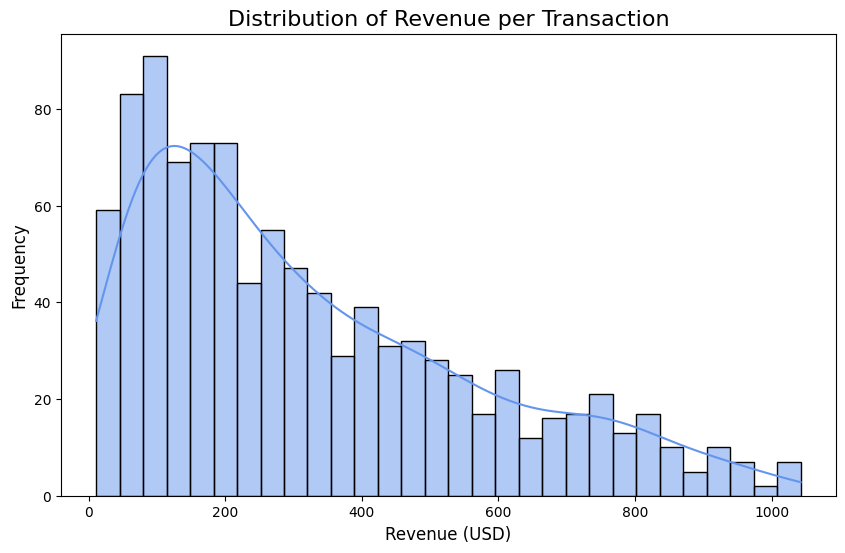

In [13]:
# 5.1: Univariate Analysis - Revenue

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select the target column for Univariate Analysis
col = 'revenue'

print(f"--- 1. Descriptive Statistics for {col} ---")
mean_val = df[col].mean()
median_val = df[col].median()
std_val = df[col].std()

# MAD calculation: Median of absolute deviations from the median
mad_val = np.median(np.abs(df[col] - median_val))

min_val = df[col].min()
max_val = df[col].max()
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr_val = q3 - q1

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")
print(f"MAD (Median Absolute Deviation): {mad_val:.2f}")
print(f"Min: {min_val:.2f} | Max: {max_val:.2f}")
print(f"Q1 (25%): {q1:.2f} | Q3 (75%): {q3:.2f}")
print(f"IQR (Interquartile Range): {iqr_val:.2f}")

print("\n--- 2. Distribution Shape ---")
skew_val = df[col].skew()
print(f"Skewness: {skew_val:.2f}")

print("\n--- 3. Outlier Detection (Method Comparison) ---")
# Method 1: 3 Standard Deviations from the Mean (Z-Score approach)
lower_std, upper_std = mean_val - 3 * std_val, mean_val + 3 * std_val
outliers_std = df[(df[col] < lower_std) | (df[col] > upper_std)]
print(f"Outliers by 3-STD: {len(outliers_std)}")

# Method 2: 3 MAD from the Median (Robust approach)
lower_mad, upper_mad = median_val - 3 * mad_val, median_val + 3 * mad_val
outliers_mad = df[(df[col] < lower_mad) | (df[col] > upper_mad)]
print(f"Outliers by 3-MAD: {len(outliers_mad)}")

# Method 3: 1.5 IQR (Tukey's Fence / Boxplot approach)
lower_iqr, upper_iqr = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
outliers_iqr = df[(df[col] < lower_iqr) | (df[col] > upper_iqr)]
print(f"Outliers by 1.5-IQR: {len(outliers_iqr)}")

# --- 4. Visualizing the Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df[col], kde=True, color='cornflowerblue', bins=30)
plt.title('Distribution of Revenue per Transaction', fontsize=16)
plt.xlabel('Revenue (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**5.2 Categorical Variables**

For this analysis, we chose to focus on the `product_line` variable, which contains 6 distinct categories and serves as a central pillar in analyzing consumer preferences.

* **Frequencies and the Mode:** By utilizing the `value_counts()` function, we identified that the most frequent category (the Mode) is **Fashion accessories**. This department accounts for **17.80%** of all transactions in the dataset.
* **Top $K$ Categories:** We chose to examine the top 3 leading categories ($K=3$). The three most common product lines are: *Fashion accessories*, *Food and beverages*, and *Electronic accessories*. Together, they encompass **52.20%** of the total data.
* **Minimum Values to Cover $P$% of the Data:** We set a target threshold of $P=80\%$. To account for at least 80% of the store's transactions, we must include the top **5** categories. These are: *Fashion accessories*, *Food and beverages*, *Electronic accessories*, *Sports and travel*, and *Home and lifestyle*.
* **Rare Categories and Value Grouping:** There are **no rare categories** in this dataset. In fact, the distribution of sales across all 6 product lines is remarkably balanced (closely resembling a Uniform Distribution), with each department representing between 15% and 17.8% of total transactions. Consequently, no single department is insignificant. There is no statistical or business justification to drop any category or group values into a generic "Other" bucket.
* **Discussion: Does the central metric represent the data well?** In the case of a categorical variable with a nearly uniform distribution, **the central metric (the Mode) is a poor representative of the overall data**. While the Mode is technically the best-selling department, it constitutes only 17.8% of the sample. This implies that if we rely solely on this central metric, we disregard over 82% of the store's transactions, which are distributed almost equally among the remaining departments. Therefore, in such a balanced dataset, relying exclusively on the Mode would lead to a severely biased understanding of the full business picture.


--- Frequencies and Percentages ---
Fashion accessories: 178 rows (17.80%)
Food and beverages: 174 rows (17.40%)
Electronic accessories: 170 rows (17.00%)
Sports and travel: 166 rows (16.60%)
Home and lifestyle: 160 rows (16.00%)
Health and beauty: 152 rows (15.20%)

--- The Mode ---
Mode: 'Fashion accessories', taking 17.80% of the data.

--- Top K (K=3) ---
Top 3 categories take 52.20% of the data.

--- P Percent (P=80%) ---
Smallest number of values to cover >= 80% of data: 5
These values are: ['Fashion accessories', 'Food and beverages', 'Electronic accessories', 'Sports and travel', 'Home and lifestyle']


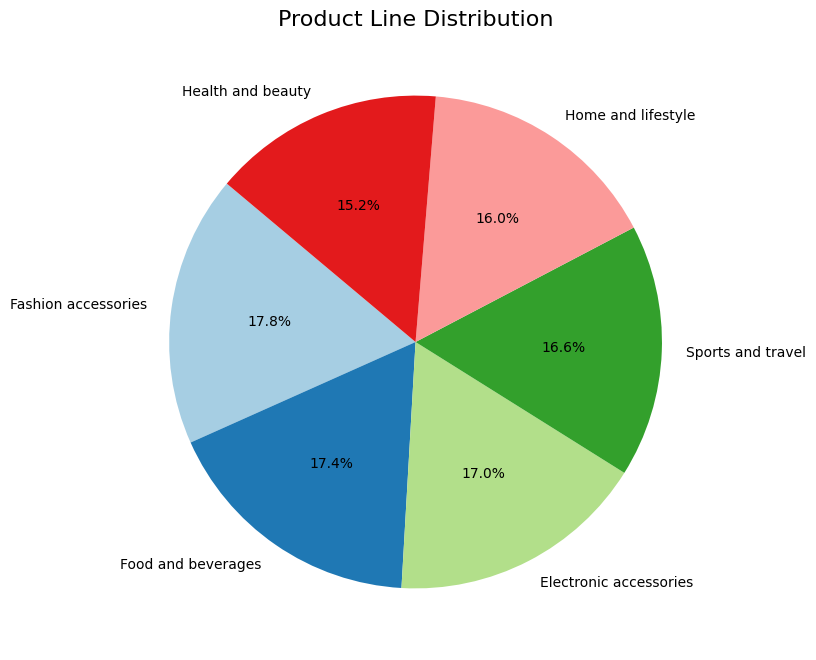

In [14]:
#5.2: Categorical Analysis - Product Line

import matplotlib.pyplot as plt

# Selecting the categorical column for analysis
col_cat = 'product_line'

# Calculating counts and normalized percentages
counts = df[col_cat].value_counts()
percs = df[col_cat].value_counts(normalize=True) * 100
cum_percs = percs.cumsum()

print("--- Frequencies and Percentages ---")
for idx, val in counts.items():
    print(f"{idx}: {val} rows ({percs[idx]:.2f}%)")

print("\n--- The Mode ---")
print(f"Mode: '{counts.index[0]}', taking {percs.iloc[0]:.2f}% of the data.")

# Calculation for Top K (K=3)
K = 3
top_k_sum = percs.iloc[:K].sum()
print(f"\n--- Top K (K={K}) ---")
print(f"Top {K} categories take {top_k_sum:.2f}% of the data.")

# Calculation for P Percent (P=80%)
P = 80
num_for_P = (cum_percs <= P).sum()
if cum_percs.iloc[num_for_P - 1] < P:
    num_for_P += 1
vals_for_P = list(cum_percs.index[:num_for_P])
print(f"\n--- P Percent (P={P}%) ---")
print(f"Smallest number of values to cover >= {P}% of data: {num_for_P}")
print(f"These values are: {vals_for_P}")

# --- Visualization: Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Product Line Distribution', fontsize=16)
plt.show()

**6. Correlations and Relationships**

**6.1 Numerical-Numerical: Relationship between Unit Cost and Total Revenue**

* **Methodology Overview:** To accurately measure the strength of the relationship between variables, we utilized three distinct statistical correlation methods as studied:
1. **Pearson:** Measures linear correlation. It is calculated using the formula $r = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$. Values range from -1 to 1, where 0 indicates no linear relationship. It assumes a normal distribution.
2. **Spearman:** Measures monotonic relationships. Unlike Pearson, this method relies on ranked values rather than raw data. Spearman is particularly useful when data is not normally distributed or when the relationship is monotonic but not strictly linear.
3. **Kendall:** Measures ordinal association by counting concordant and discordant pairs. This method is often preferred for smaller datasets or ordinal variables and tends to be more conservative.


* **Correlation Results:**
* **Pearson:** 0.634
* **Spearman:** 0.630
* **Kendall:** 0.465


* **Correlation Matrix and Scatter Plot:** We generated a Correlation Matrix (Heatmap) to display the linear relationships across all numerical variables. The matrix clearly demonstrates that `revenue` has the strongest correlation with `quantity` (0.71) and `unit_cost` (0.63). Furthermore, a scatter plot was created to visually illustrate the relationship between unit cost and revenue.
* **Insights and Conclusions:**
1. **Significant Positive Correlation:** All three metrics indicate a strong positive correlation (values are far from 0). Naturally, as the base price of a product increases, the final transaction revenue increases.
2. **Linearity:** The near-identical values of the Spearman (0.630) and Pearson (0.634) coefficients strongly reinforce the assumption that the relationship is distinctly linear.
3. **The "Fan" Pattern in the Scatter Plot:** In the scatter plot, the data points do not form a random cloud; instead, they are arranged in distinct diagonal "rays" or lines. The reason for this is mathematical/business-driven: The transaction revenue is calculated by multiplying the unit cost by a discrete integer quantity (plus a flat 5% tax). Because the quantity of items is always a whole number (between 1 and 10), each diagonal line in the plot represents a different quantity multiplier. The lowest line represents transactions of a single item, the line above it represents 2 items, and so forth.

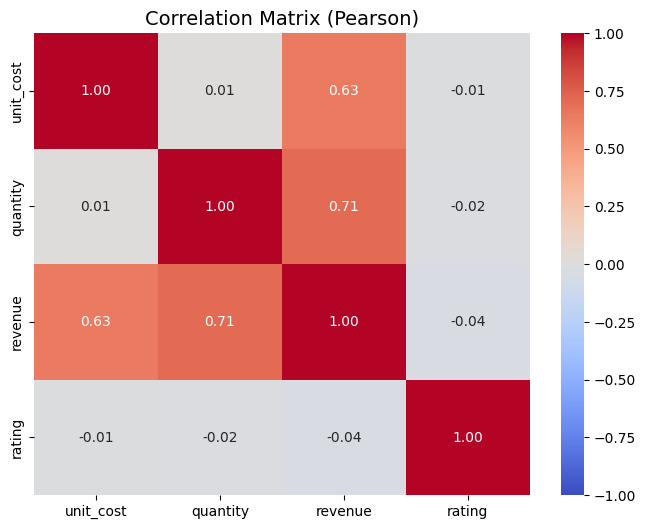


--- Correlation Values ---
Pearson:  0.634
Spearman: 0.630
Kendall:  0.465


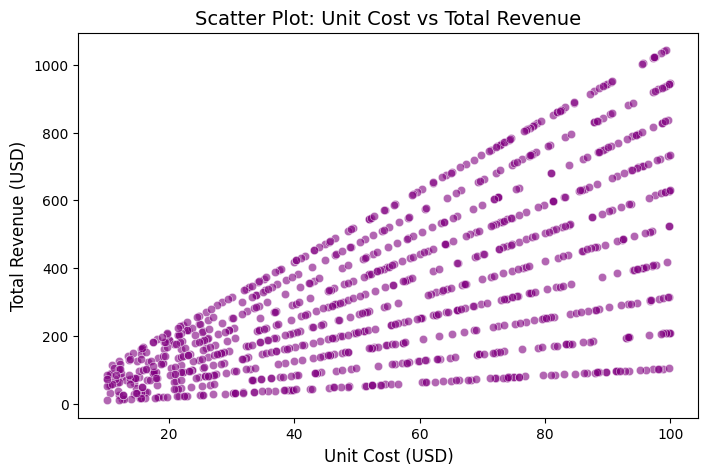

In [16]:
# 6.1: Correlations - Unit Cost vs Total Revenue

import seaborn as sns
import matplotlib.pyplot as plt


# 1. Correlation Matrix (Pearson) for core numerical variables
numeric_vars = ['unit_cost', 'quantity', 'revenue', 'rating']
corr_matrix = df[numeric_vars].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix (Pearson)', fontsize=14)
plt.show()

# 2. Calculating 3 correlation types for Unit Cost and Revenue
col1, col2 = 'unit_cost', 'revenue'
pearson_val = df[col1].corr(df[col2], method='pearson')
spearman_val = df[col1].corr(df[col2], method='spearman')
kendall_val = df[col1].corr(df[col2], method='kendall')

print("\n--- Correlation Values ---")
print(f"Pearson:  {pearson_val:.3f}")
print(f"Spearman: {spearman_val:.3f}")
print(f"Kendall:  {kendall_val:.3f}")

# 3. Scatter Plot visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[col1], y=df[col2], alpha=0.6, color='purple')
plt.title('Scatter Plot: Unit Cost vs Total Revenue', fontsize=14)
plt.xlabel('Unit Cost (USD)', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.show()

**6.2 Categorical-Categorical Relationships**

In this section, we investigated the relationship between the customer's membership status (`customer_type`) and the size of their transaction.

* **Binning a Numerical Variable:** To analyze the relationship between a categorical and a numerical variable using categorical tools, we performed discretization (Binning) on the continuous `revenue` variable. Utilizing the `pd.qcut` function, we divided all transactions into 3 equal-sized bins (tertiles): **Low**, **Medium**, and **High**. This created a new categorical column named `revenue_binned`.
* **Crosstab (Frequency Table):** We generated a cross-tabulation between the original `customer_type` variable and the newly binned `revenue_binned` variable. As evidenced by the code output, the distribution within the table is almost perfectly symmetrical. Both "Normal" customers and "Members" are distributed equally across the low, medium, and high transaction brackets (ranging narrowly between 162-171 transactions per segment).
* **Cramér's V:** To mathematically validate our observations from the crosstab, we calculated Cramér's V, a metric designed to measure the strength of association between two nominal/categorical variables. The resulting score is **0.000**.
* **Actionable Business Insights:**
* **Absence of Correlation:** The absolute zero score of Cramér's V, coupled with the uniform distribution in the frequency table, conclusively proves that **there is no relationship between a customer's membership status and their total expenditure.**
* **Business Implication:** The supermarket chain is failing to leverage its customer loyalty program to encourage larger purchases (Upselling). A "Member" is just as likely to spend a specific amount as a "Normal" walk-in customer. This strongly indicates that the current loyalty program does not provide adequate incentives for customers to increase their basket size.

In [18]:
# 6.2: Categorical-Categorical - Member vs Revenue

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


print("--- 1. Binning (Discretization) ---")
# Converting the continuous 'revenue' variable into a categorical one by dividing it into 3 equal quantiles (tertiles)
df['revenue_binned'] = pd.qcut(df['revenue'], q=3, labels=['Low', 'Medium', 'High'])
print("Created new categorical column: 'revenue_binned' (Low, Medium, High)\n")

print("--- 2. Crosstab (Frequency Table) ---")
# Creating a cross-tabulation between customer type and the new revenue bins
crosstab_result = pd.crosstab(df['customer_type'], df['revenue_binned'], margins=True, margins_name="Total")
print(crosstab_result)

print("\n--- 3. Cramér's V (Categorical Association Metric) ---")
# Function to calculate Cramér's V statistic
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cv_score = cramers_v(df['customer_type'], df['revenue_binned'])
print(f"Cramér's V score: {cv_score:.3f}")

--- 1. Binning (Discretization) ---
Created new categorical column: 'revenue_binned' (Low, Medium, High)

--- 2. Crosstab (Frequency Table) ---
revenue_binned  Low  Medium  High  Total
customer_type                           
Member          164     166   171    501
Normal          170     167   162    499
Total           334     333   333   1000

--- 3. Cramér's V (Categorical Association Metric) ---
Cramér's V score: 0.000


**6.3 Visualizations and Business Insights**

In this section, we generated a diverse array of charts to visualize the data and extract actionable business intelligence. All graphs include appropriate titles, axis labels, and legends.

* **1. Scatterplot: COGS vs. Revenue by Gender**
* **Insight:** The plot displays a perfect diagonal line. This is because Total Revenue is derived directly from the Cost of Goods Sold (COGS) with a fixed 5% tax markup. The color distribution reveals that transactions by both genders are scattered randomly along this line, proving that neither gender has a dominant tendency to make more expensive purchases than the other.


* **2. Histogram: Customer Rating Distribution**
* **Insight:** The histogram (overlaid with a KDE curve) demonstrates that the distribution of customer satisfaction is nearly uniform and flat across the 4 to 10 scale. There is no single heavily concentrated score, indicating a highly mixed customer experience across the branches without a strong positive or negative consensus.


* **3. Barchart: Total Revenue by Product Line**
* **Insight:** This chart highlights the primary revenue drivers for the store. "Food and beverages" and "Sports and travel" are the top-grossing departments, whereas "Health and beauty" generates the least amount of revenue.


* **4. Boxplot: Revenue Distribution by Payment Method**
* **Insight:** The boxes for all three payment methods (Ewallet, Cash, Credit card) are almost identical in their interquartile ranges and medians. This overlap indicates that a customer's choice of payment method is completely independent of their transaction size.


* **5. Violin Plot: Rating Distribution by Gender**
* **Insight:** The violin plot illustrates data density. While both violins share a similar overall shape, the distribution for female customers shows a slightly higher concentration (a "bulge") of ratings in the 7-8 range compared to male customers.


* **6. Piechart: Payment Method Preferences**
* **Insight:** The market share of payment methods is split almost equally into thirds: Ewallet (34.5%), Cash (34.4%), and Credit card (31.1%). This demonstrates a very high adoption rate of digital payment technologies existing comfortably alongside traditional cash.


* **7. Pairplot: Numerical Variable Relationships**
* **Insight:** This macro-level grid displays all pairwise numerical relationships. It prominently features the neat vertical columns of `quantity` (since it strictly uses integers 1-10) and reiterates the perfect linear correlation between `unit_cost` and `revenue`.


* **8. Heatmap: Average Revenue by City and Customer Type**
* **Insight:** The heatmap exposes geographical nuances. For instance, in Naypyitaw, the average transaction is relatively high for both customer types (around 336-337). However, in Yangon, there is a noticeable disparity, with "Members" averaging higher spends (321.2) than "Normal" customers (303.8).

--- 1. Scatterplot ---


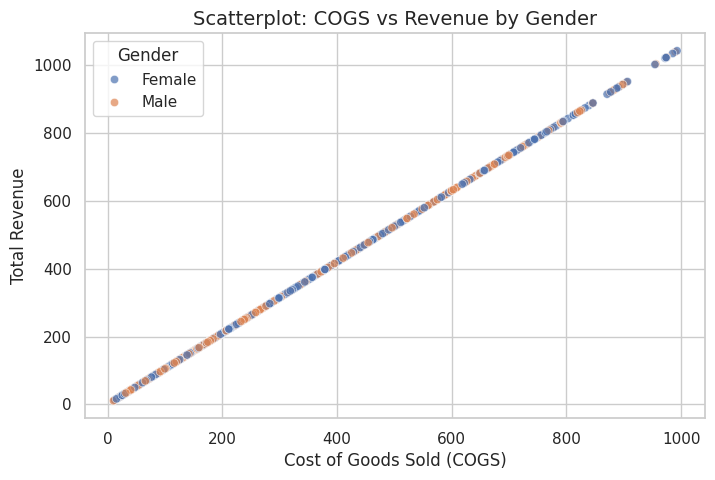


--- 2. Histogram ---


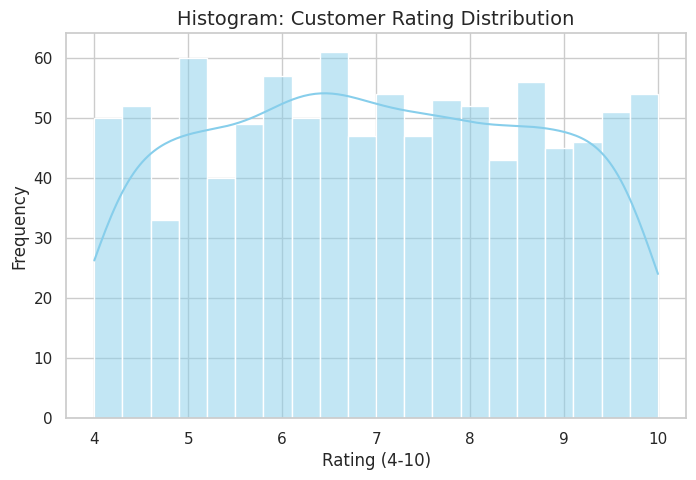


--- 3. Barchart ---


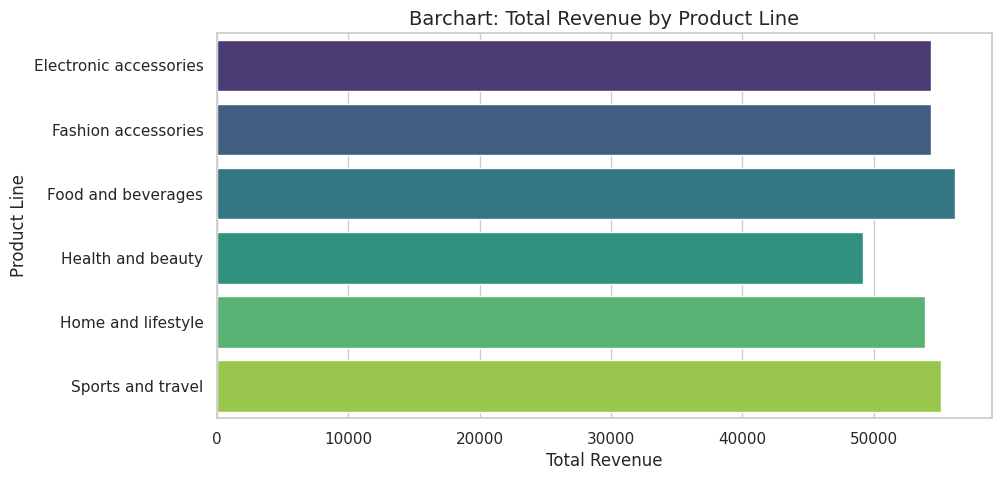


--- 4. Boxplot ---


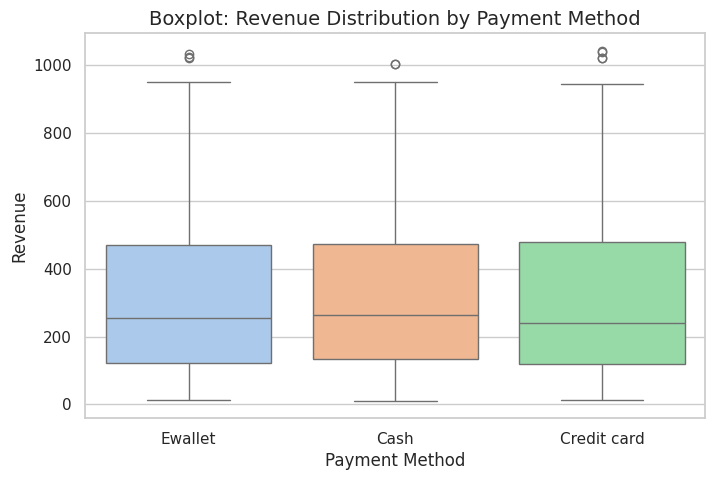


--- 5. Violin Plot ---


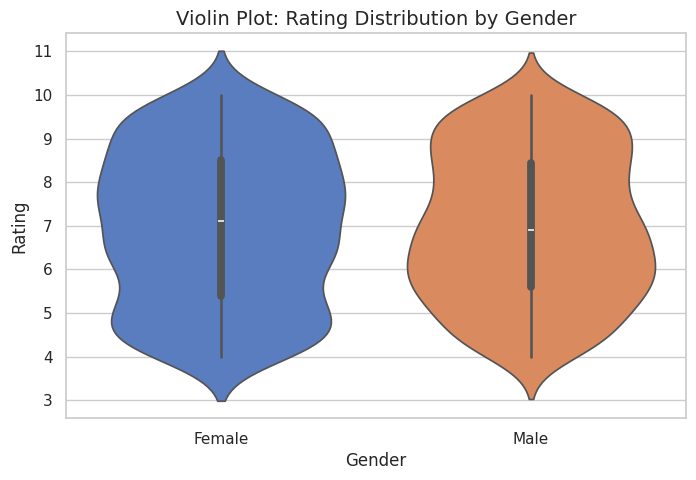


--- 6. Piechart ---


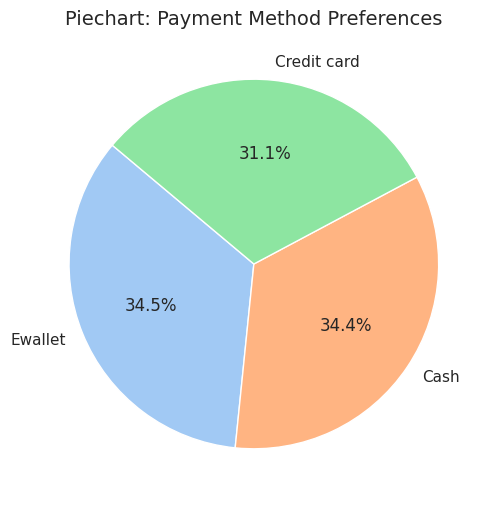


--- 7. Pairplot ---


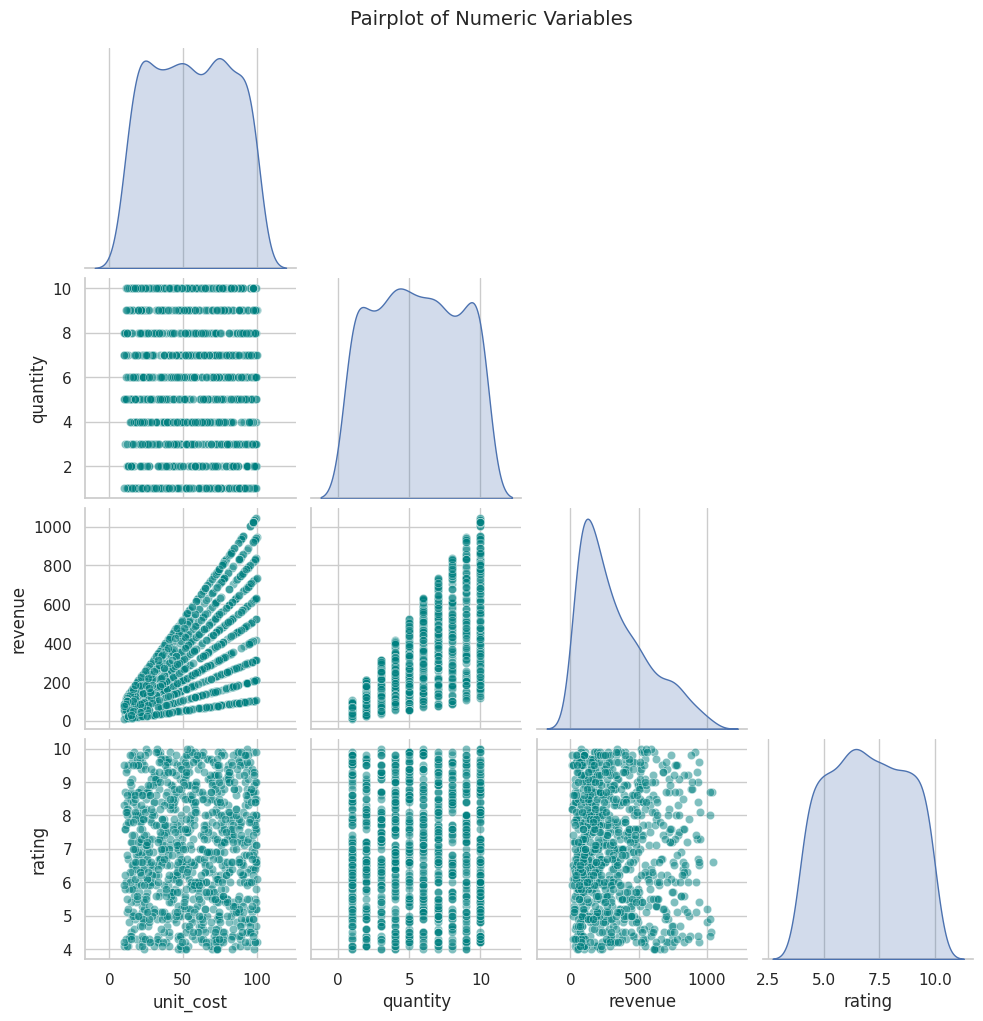


--- 8. Heatmap ---


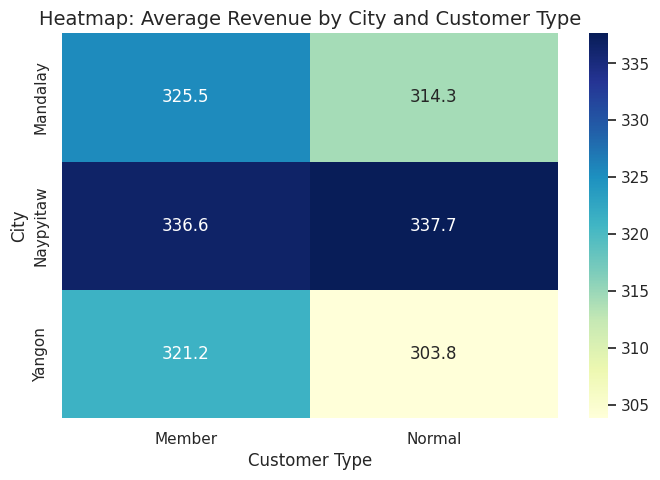

In [20]:
# 6.3: Visualizations and Insights

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme for all plots
sns.set_theme(style="whitegrid")

print("--- 1. Scatterplot ---")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='cogs', y='revenue', hue='gender_customer', alpha=0.7)
plt.title('Scatterplot: COGS vs Revenue by Gender', fontsize=14)
plt.xlabel('Cost of Goods Sold (COGS)', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.legend(title='Gender')
plt.show()

print("\n--- 2. Histogram ---")
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='rating', bins=20, kde=True, color='skyblue')
plt.title('Histogram: Customer Rating Distribution', fontsize=14)
plt.xlabel('Rating (4-10)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

print("\n--- 3. Barchart ---")
plt.figure(figsize=(10, 5))
revenue_by_product = df.groupby('product_line')['revenue'].sum().reset_index()
# Fixed the future warning by assigning hue
sns.barplot(data=revenue_by_product, x='revenue', y='product_line', hue='product_line', palette='viridis', legend=False)
plt.title('Barchart: Total Revenue by Product Line', fontsize=14)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Line', fontsize=12)
plt.show()

print("\n--- 4. Boxplot ---")
plt.figure(figsize=(8, 5))
# Fixed the future warning by assigning hue
sns.boxplot(data=df, x='payment_method', y='revenue', hue='payment_method', palette='pastel', legend=False)
plt.title('Boxplot: Revenue Distribution by Payment Method', fontsize=14)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.show()

print("\n--- 5. Violin Plot ---")
plt.figure(figsize=(8, 5))
# Fixed the future warning by assigning hue
sns.violinplot(data=df, x='gender_customer', y='rating', hue='gender_customer', palette='muted', legend=False)
plt.title('Violin Plot: Rating Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

print("\n--- 6. Piechart ---")
plt.figure(figsize=(6, 6))
payment_counts = df['payment_method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Piechart: Payment Method Preferences', fontsize=14)
plt.show()

print("\n--- 7. Pairplot ---")
numeric_cols = ['unit_cost', 'quantity', 'revenue', 'rating']
sns.pairplot(df[numeric_cols], corner=True, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'teal'})
plt.suptitle('Pairplot of Numeric Variables', y=1.02, fontsize=14)
plt.show()

print("\n--- 8. Heatmap ---")
plt.figure(figsize=(8, 5))
pivot_df = df.pivot_table(index='city', columns='customer_type', values='revenue', aggfunc='mean')
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Heatmap: Average Revenue by City and Customer Type', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

**7. Index Analysis**

Using built-in Pandas functions (such as `is_unique` and `is_monotonic_increasing`), we examined the index properties of our dataset:

* **Is the index unique? Yes.** By default, Pandas generated a numerical `RangeIndex` for the DataFrame (from 0 to 999). Each row receives its own identifier, making the index 100% unique. (Additionally, the dataset contains a transaction identifier column, `invoice_id`, which is also entirely unique for each record).
* **Is it time-based? No.** The current index is a continuous numerical index, not a `DatetimeIndex`. Although the database contains date and time columns (`date`, `time`), we did not set them as the DataFrame's index during our analysis.
* **Does the above analysis change over time?** The analyses we performed in the previous sections (averages, correlations, distributions in graphs) were **aggregative**; we looked at the entire 3 months of data as a single, static "snapshot." However, in the real retail world, data certainly changes over time. If we were to perform a Time Series analysis, we would likely discover seasonality, purchasing peaks on certain days of the week (e.g., weekends), or specific rush hours throughout the day (e.g., evening hours after work) where the shopping basket differs.
* **Is it sorted? Yes.** The numerical `RangeIndex` is naturally sorted in ascending order (from 0 to 999). However, it's important to note that if we examine the date column itself, the rows in the original file are not necessarily arranged in chronological order from the store's opening day to the last day; they are simply numbered sequentially as they appear in the CSV file.

In [22]:
# 7: Index Analysis

import pandas as pd

print("--- Index Properties ---")
print(f"1. Index type: {type(df.index)}")
print(f"2. Is index unique? {df.index.is_unique}")
print(f"3. Is index time-based? {isinstance(df.index, pd.DatetimeIndex)}")
print(f"4. Is index sorted (monotonic increasing)? {df.index.is_monotonic_increasing}")

--- Index Properties ---
1. Index type: <class 'pandas.core.indexes.range.RangeIndex'>
2. Is index unique? True
3. Is index time-based? False
4. Is index sorted (monotonic increasing)? True


**8. Insights and Data Storytelling**

**Project Summary:** In this project, we analyzed a supermarket chain dataset encompassing 1,000 transactions across 3 distinct branches. We executed an end-to-end data science process: from loading the data and checking for missing values (which were absent), through univariate analysis, to discovering correlations and producing comprehensive visualizations. The primary objective was to decode consumer behavior and identify the store's core growth engines.

**Three Key Insights:**

1. **The Loyalty Program Fails at Upselling:** The data mathematically proved (Cramér's V = 0) that there is zero difference in spending habits between "Members" and "Normal" walk-in customers. The loyalty program currently fails to incentivize larger shopping baskets; it serves merely as a "status" label with no tangible impact on the bottom line.
2. **Absolute Adoption of Digital Payments:** Unlike the past where cash was king, today's payment methods are divided almost perfectly into thirds. Electronic wallets (Ewallet) have emerged as the leading payment method by a narrow margin (34.5%). This necessitates that the retail chain ensures rapid, smart payment infrastructure at the checkout counters.
3. **Uniform Distribution and the Absence of "Stars":** Sales are distributed almost entirely uniformly across all 6 product departments, as well as between genders. No single department carries the supermarket's revenue on its back, and neither gender spends significantly more than the other.

**Primary Bias / Risk in the Data:**

* **Selection/Time Bias:** The dataset contains transactions strictly from a 3-month window (January to March). This poses a massive risk to any analysis, as it completely ignores the inherent seasonality of the retail world. Any model based solely on this data will miss the summer months, major holidays, the start of the school year, and end-of-year sales events (like Black Friday). Consequently, it cannot reliably forecast annual revenue.

**Potential Points of Failure for Machine Learning Models:**

* **Lack of Variance:** Machine Learning models require variance in variables to detect patterns. In our dataset, many categorical variables are suspiciously balanced (near 50/50 gender split, exactly 33% for each payment method, equal product line sales). A classification model will struggle to find meaningful splits in such homogenous data, likely leading to underfitting or poor predictive performance.
* **Data Leakage / Deterministic Relationships:** Attempting to predict the `revenue` target column using `unit_cost` and `quantity` would be a fundamental modeling error. This relationship is a closed mathematical formula ($Price \times Quantity + 5\% Tax$). The model would achieve 100% accuracy but would be completely devoid of any real analytical value.

**What I Learned and How My Perspective Changed:**
This workflow taught me that Data Analysis is not merely executing technical functions; it demands critical thinking regarding the *nature* of the information. A fundamental shift in my perspective concerns data quality: I previously assumed that "clean data" (devoid of outliers and missing values) was the absolute ideal. However, this analysis (particularly from Section 4) vividly illustrated that data which is "too perfect and balanced" – such as a dataset without a single negative transaction reflecting a product return – is almost certainly manipulated or synthetic. In the real world of Data Science, it is precisely the "dirt" (cancellations, missing fields, extreme anomalies from giant clients) that tells the true, authentic story of the business.

**9. Bonus: Advanced Investigation**

* **Time Dependence and External Information:** The dataset records transactions from the first quarter of 2019 (January–March). External knowledge of calendar dynamics suggests that consumer behavior frequently shifts between weekdays and weekends. To investigate this time dependence, we extracted the days of the week and discovered clear volatility: **The weekend (Saturday and Sunday) exhibits the highest average transaction revenue** (approximately $334 to $342 per transaction), while Mondays and Wednesdays show the lowest. This highlights a consumer pattern of larger purchases during rest and leisure days.
* **Feature Engineering:** To empower Machine Learning models to explore the temporal dimension, we performed feature engineering on the `date` column. We engineered two new features:
* `day_of_week`: Extracts the explicit name of the day (e.g., Saturday).
* `is_weekend`: A binary column (0 or 1) indicating whether the transaction occurred on a weekend. These features enable the discovery of new correlations that are hidden within the original raw date format.


* **Hypothesis Testing:** We conducted an Independent Two-Sample T-Test to statistically validate an insight that emerged earlier: Does the average revenue of Members differ from that of Normal customers?
* **Null Hypothesis ($H_0$):** $\mu_{Member} = \mu_{Normal}$ (There is no difference in the means).
* **Result:** We obtained a P-value of **0.534**.
* **Conclusion:** Because the P-value is significantly greater than the standard alpha level of 0.05, we **fail to reject the Null Hypothesis**. We have statistically proven that the store's loyalty program does not increase the average customer expenditure.


* **Proposals for Future Research:**
1. **Time Series Forecasting:** Utilizing models such as ARIMA or Prophet on the date and revenue columns (aggregated daily) to forecast the store's revenue for the upcoming quarter and identify long-term macro-seasonality.
2. **Market Basket Analysis:** If the dataset is enriched in the future to include specific SKU identifiers within the same invoice, algorithms like Apriori could be deployed. This would identify which product departments or items are frequently purchased together (e.g., whether electronics are bought immediately after lifestyle equipment), enabling targeted cross-selling and product placement recommendations.

In [26]:
# 9: Bonus - Advanced Investigation

import pandas as pd
from scipy import stats


print("--- 1. Feature Engineering & Time Dependence ---")
# שימוש בפורמט mixed מאפשר ל-Pandas להתמודד עם תאריכים בפורמטים שונים או לזהות אותם אוטומטית בצורה הטובה ביותר
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Feature Engineering: Extracting the day of the week and creating a weekend binary indicator
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

print("Created new features: 'day_of_week' and 'is_weekend'\n")

print("Average Revenue by Day of Week:")
print(df.groupby('day_of_week')['revenue'].mean().sort_values(ascending=False))

print("\n--- 2. Hypothesis Testing (Independent T-Test) ---")
# Null Hypothesis (H0): No difference in average revenue between Members and Normal customers
# Alternative Hypothesis (H1): There is a significant difference
member_rev = df[df['customer_type'] == 'Member']['revenue']
normal_rev = df[df['customer_type'] == 'Normal']['revenue']

t_stat, p_val = stats.ttest_ind(member_rev, normal_rev)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3f}")

if p_val < 0.05:
    print("Conclusion: Reject H0 -> There is a significant difference.")
else:
    print("Conclusion: Fail to reject H0 -> No significant difference.")

--- 1. Feature Engineering & Time Dependence ---
Created new features: 'day_of_week' and 'is_weekend'

Average Revenue by Day of Week:
day_of_week
Saturday     342.200058
Sunday       334.269868
Thursday     328.617739
Tuesday      325.836997
Friday       316.016838
Wednesday    305.812133
Monday       303.192624
Name: revenue, dtype: float64

--- 2. Hypothesis Testing (Independent T-Test) ---
T-statistic: 0.622
P-value: 0.534
Conclusion: Fail to reject H0 -> No significant difference.
